In [1]:

#cartopy data directory structure
#src = "/path/to/CARTOPY_DATA_DIR"+"/shapefiles/natural_earth/physical/"


#shutil.copytree(src, dst)

In [1]:
import os
from torch.utils.data import Dataset, DataLoader

import numpy as np
import sys
import torch.nn as nn
import torch
from torch_geometric.utils import degree
import matplotlib.pyplot as plt
os.environ["CARTOPY_DATA_DIR"] = "/leonardo_work/ICT25_ESP/sdigioia/CORDEX-ML/cartopy/"

import pickle


import matplotlib

sys.path.append("/leonardo_work/ICT25_ESP/sdigioia/CORDEX-ML/GNN4CD-CORDEXML")
from utils.plots import extremes_cmap
from utils.tools import date_to_idxs_new, prepare_target_Rall, prepare_target_T_Rall, find_not_all_nan_times_new, derive_train_val_idxs_new

import matplotlib.ticker as ticker
import matplotlib.colors as colors
import matplotlib.patches as patches
# import colorcet as cc

import warnings
warnings.filterwarnings("ignore")

from matplotlib.ticker import ScalarFormatter, NullFormatter
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

In [2]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature



import sys
#sys.path.append('evaluation')
#import indices, diagnostics

In [3]:
DOMAIN="SA"
EXPERIMENT="ESD_pseudo_reality"

training_experiment=EXPERIMENT
if DOMAIN == 'ALPS':
    gcm_name = 'CNRM-CM5'
elif DOMAIN == 'NZ':
    gcm_name = ''
else:
    gcm_name = 'ACCESS-CM2'

period_training = '1961-1980'

import xarray as xr

In [71]:
if DOMAIN== 'SA':
    output_graph_path=f"/leonardo_work/ICT25_ESP_0/wtang/CORDEXML-GRAPHS/"
    target_input_path=f'/leonardo_work/ICT25_ESP_0/wtang/CORDEXML-BENCHMARK/{DOMAIN}_domain/train/{EXPERIMENT}/target/'
    predictor_input_path=f'/leonardo_work/ICT25_ESP_0/wtang/CORDEXML-BENCHMARK/{DOMAIN}_domain/train/{EXPERIMENT}/predictors/'
    
else:
    output_graph_path=f"/leonardo_work/ICT25_ESP/sdigioia/CORDEX-ML/CORDEX-graphs/{DOMAIN}_domain/{EXPERIMENT}/"
    target_input_path=f'/leonardo_work/ICT25_ESP/sdigioia/CORDEX-ML/CORDEX-domains/{DOMAIN}_domain/train/{EXPERIMENT}/target/'
    predictor_input_path=f'/leonardo_work/ICT25_ESP/sdigioia/CORDEX-ML/CORDEX-domains/{DOMAIN}_domain/train/{EXPERIMENT}/predictors/'


In [5]:

original_target_file=target_input_path + f'pr_tasmax_{gcm_name}_{period_training}.nc'
target_tasmax_file="new_target_tasmax.pkl"



In [6]:
topo_file=predictor_input_path + f'Static_fields.nc'
predictor_filename = predictor_input_path + f'{gcm_name}_{period_training}.nc'


In [7]:
predictor = xr.open_dataset(predictor_filename, engine="netcdf4")

In [8]:
levels=np.array([850,700,500]) 

n_levels=len(levels)
n_params=5
time_dim = len(predictor['time']) #7305 in ESD experiment


In [9]:
print(predictor)

<xarray.Dataset>
Dimensions:    (time: 7300, bnds: 2, lon: 16, lat: 16)
Coordinates:
  * time       (time) datetime64[ns] 1961-01-01T12:00:00 ... 1980-12-31T12:00:00
  * lon        (lon) float64 11.0 13.0 15.0 17.0 19.0 ... 35.0 37.0 39.0 41.0
  * lat        (lat) float64 -40.0 -38.0 -36.0 -34.0 ... -16.0 -14.0 -12.0 -10.0
Dimensions without coordinates: bnds
Data variables: (12/16)
    time_bnds  (time, bnds) datetime64[ns] ...
    t_500      (time, lat, lon) float32 ...
    t_700      (time, lat, lon) float32 ...
    t_850      (time, lat, lon) float32 ...
    u_500      (time, lat, lon) float32 ...
    u_700      (time, lat, lon) float32 ...
    ...         ...
    z_500      (time, lat, lon) float32 ...
    z_700      (time, lat, lon) float32 ...
    z_850      (time, lat, lon) float32 ...
    q_500      (time, lat, lon) float32 ...
    q_700      (time, lat, lon) float32 ...
    q_850      (time, lat, lon) float32 ...
Attributes: (12/259)
    CDI:                  Climate Data Int

In [10]:
sliced_predictor = predictor.sel(lat=slice(-36, -22), lon=slice(20, 35))
lat_low = sliced_predictor['lat']
lon_low = sliced_predictor['lon']
lat_dim = len(lat_low.values[:]) #16
lon_dim = len(lon_low.values[:]) #16

input_ds = np.zeros((time_dim, n_params, n_levels, lat_dim, lon_dim), dtype=np.float32)

In [11]:
print(lat_low)
print(lon_low)

<xarray.DataArray 'lat' (lat: 8)>
array([-36., -34., -32., -30., -28., -26., -24., -22.])
Coordinates:
  * lat      (lat) float64 -36.0 -34.0 -32.0 -30.0 -28.0 -26.0 -24.0 -22.0
Attributes:
    standard_name:  latitude
    long_name:      latitude
    units:          degrees_north
    axis:           Y
<xarray.DataArray 'lon' (lon: 8)>
array([21., 23., 25., 27., 29., 31., 33., 35.])
Coordinates:
  * lon      (lon) float64 21.0 23.0 25.0 27.0 29.0 31.0 33.0 35.0
Attributes:
    standard_name:  longitude
    long_name:      longitude
    units:          degrees_east
    axis:           X


In [12]:
print(sliced_predictor['q_500'].values[:].shape)

(7300, 8, 8)


In [13]:

#lat_low = np.flip(lat_low, axis=0)  # Flip the latitude array along the first axis
lat_low_2D, lon_low_2D = np.meshgrid(lat_low.values[:], lon_low.values[:], indexing='ij')
print(lon_low_2D[2,1], lat_low_2D[2,1])

23.0 -32.0


In [14]:

params = ['q', 't', 'u', 'v', 'z']
predictor_vars=np.array(params)
for var_idx, p in enumerate(predictor_vars):
  print(p)
  for l_idx, level in enumerate(['850', '700','500']):
                var_name = f"{p}_{level}"
                _data = sliced_predictor[var_name].values[:]
                _data = torch.from_numpy(_data)
                input_ds[:, var_idx,l_idx,:,:] = _data.numpy()
        



q
t
u
v
z


In [15]:
print(input_ds.shape) #time, vars,levels, lat, lon

(7300, 5, 3, 8, 8)


In [16]:
input_ds = torch.tensor(input_ds)

In [17]:
input_ds = torch.permute(input_ds, (3,4,0,1,2)) # lat, lon, time, vars, levels
print(input_ds.shape)
input_ds = torch.flatten(input_ds, end_dim=1)   # num_nodes, time, vars, levels
print(input_ds.shape)

torch.Size([8, 8, 7300, 5, 3])
torch.Size([64, 7300, 5, 3])


In [18]:
lat_low_1D = lat_low_2D.flatten()
lon_low_1D = lon_low_2D.flatten()

In [19]:
#low-resol statistics estimations
mean_arr=np.zeros((5,3))
fixed_time_mean_arr=np.zeros((time_dim, 15))
fixed_time_std_arr=np.zeros((time_dim, 15))
std_arr=np.zeros((5,3))
for i_var in range(5):
    for j_level in range(3):
        #print(torch.min(input_ds[:,0,i_var,j_level]),torch.max(input_ds[:,0,i_var,j_level]), torch.mean(input_ds[:,0,i_var,j_level]))
        mean_arr[i_var, j_level]= torch.mean(input_ds[:,:,i_var,j_level]).numpy()
        std_arr[i_var, j_level]=torch.std(input_ds[:,:,i_var,j_level]).numpy()
        fixed_time_std_arr[:,i_var*3+j_level]=torch.std(input_ds[:,:,i_var,j_level], dim=0).numpy()
        fixed_time_mean_arr[:,i_var*3+j_level]=torch.mean(input_ds[:,:,i_var,j_level], dim=0).numpy()
        

print(mean_arr)
print(std_arr)

[[ 7.11104739e-03  3.79742356e-03  1.09826936e-03]
 [ 2.86883606e+02  2.78680573e+02  2.61905731e+02]
 [ 3.74754459e-01  5.32869053e+00  1.08325596e+01]
 [-1.46510506e+00 -1.38302052e+00 -1.30404389e+00]
 [ 1.53985449e+03  3.13890332e+03  5.80600928e+03]]
[[2.93705380e-03 2.30867253e-03 8.34016071e-04]
 [5.90731239e+00 4.70376682e+00 4.55259180e+00]
 [5.69043875e+00 6.77323675e+00 9.60353756e+00]
 [5.39137554e+00 4.91073370e+00 6.80274200e+00]
 [7.32940903e+01 4.55527420e+01 7.63182678e+01]]


In [20]:
#To save stats uncomment below
np.savez("fixed_time_statistics_predictors_SA.npz", mean=fixed_time_mean_arr, std=fixed_time_std_arr)

In [21]:
np.savez("statistics_predictors_SA.npz", mean=mean_arr, std=std_arr)

In [22]:
print(mean_arr[0,0])
print(fixed_time_mean_arr[0:10, 0])
print(params)
print(mean_arr[1,0])
print(fixed_time_mean_arr[0:10, 3])

0.0071110473945736885
[0.00761822 0.00684338 0.00621289 0.00509043 0.00501094 0.00697043
 0.00695524 0.00710767 0.00790664 0.0087819 ]
['q', 't', 'u', 'v', 'z']
286.88360595703125
[293.35836792 293.61764526 294.28063965 294.74411011 294.86651611
 293.62783813 293.78500366 294.42828369 294.60784912 290.57275391]


In [23]:
print(input_ds[0:10, 0, 0, 0],lon_low_1D[0:10],lat_low_1D[0:10])

tensor([0.0038, 0.0060, 0.0069, 0.0053, 0.0049, 0.0054, 0.0043, 0.0018, 0.0092,
        0.0091]) [21. 23. 25. 27. 29. 31. 33. 35. 21. 23.] [-36. -36. -36. -36. -36. -36. -36. -36. -34. -34.]


In [24]:

predictand=xr.open_dataset(original_target_file, engine="netcdf4")



In [25]:
T_target_high = predictand.tasmax

In [26]:
T_target_high.shape

(7300, 128, 128)

In [27]:
lon_high=predictand.lon

In [35]:
lon_high

<xarray.DataArray 'lon' (lon: 128)>
array([20.5, 20.6, 20.7, 20.8, 20.9, 21. , 21.1, 21.2, 21.3, 21.4, 21.5, 21.6,
       21.7, 21.8, 21.9, 22. , 22.1, 22.2, 22.3, 22.4, 22.5, 22.6, 22.7, 22.8,
       22.9, 23. , 23.1, 23.2, 23.3, 23.4, 23.5, 23.6, 23.7, 23.8, 23.9, 24. ,
       24.1, 24.2, 24.3, 24.4, 24.5, 24.6, 24.7, 24.8, 24.9, 25. , 25.1, 25.2,
       25.3, 25.4, 25.5, 25.6, 25.7, 25.8, 25.9, 26. , 26.1, 26.2, 26.3, 26.4,
       26.5, 26.6, 26.7, 26.8, 26.9, 27. , 27.1, 27.2, 27.3, 27.4, 27.5, 27.6,
       27.7, 27.8, 27.9, 28. , 28.1, 28.2, 28.3, 28.4, 28.5, 28.6, 28.7, 28.8,
       28.9, 29. , 29.1, 29.2, 29.3, 29.4, 29.5, 29.6, 29.7, 29.8, 29.9, 30. ,
       30.1, 30.2, 30.3, 30.4, 30.5, 30.6, 30.7, 30.8, 30.9, 31. , 31.1, 31.2,
       31.3, 31.4, 31.5, 31.6, 31.7, 31.8, 31.9, 32. , 32.1, 32.2, 32.3, 32.4,
       32.5, 32.6, 32.7, 32.8, 32.9, 33. , 33.1, 33.2], dtype=float32)
Coordinates:
  * lon      (lon) float32 20.5 20.6 20.7 20.8 20.9 ... 32.8 32.9 33.0 33.1 33.2
Attributes:
    standard_name:  longitude
    long_name:      longitude
    units:          degrees_east
    axis:           X
    bounds:         lon_bnds

In [28]:
lat_high=predictand.lat

In [29]:
lat_high

<xarray.DataArray 'lat' (lat: 128)>
array([-34.7, -34.6, -34.5, -34.4, -34.3, -34.2, -34.1, -34. , -33.9, -33.8,
       -33.7, -33.6, -33.5, -33.4, -33.3, -33.2, -33.1, -33. , -32.9, -32.8,
       -32.7, -32.6, -32.5, -32.4, -32.3, -32.2, -32.1, -32. , -31.9, -31.8,
       -31.7, -31.6, -31.5, -31.4, -31.3, -31.2, -31.1, -31. , -30.9, -30.8,
       -30.7, -30.6, -30.5, -30.4, -30.3, -30.2, -30.1, -30. , -29.9, -29.8,
       -29.7, -29.6, -29.5, -29.4, -29.3, -29.2, -29.1, -29. , -28.9, -28.8,
       -28.7, -28.6, -28.5, -28.4, -28.3, -28.2, -28.1, -28. , -27.9, -27.8,
       -27.7, -27.6, -27.5, -27.4, -27.3, -27.2, -27.1, -27. , -26.9, -26.8,
       -26.7, -26.6, -26.5, -26.4, -26.3, -26.2, -26.1, -26. , -25.9, -25.8,
       -25.7, -25.6, -25.5, -25.4, -25.3, -25.2, -25.1, -25. , -24.9, -24.8,
       -24.7, -24.6, -24.5, -24.4, -24.3, -24.2, -24.1, -24. , -23.9, -23.8,
       -23.7, -23.6, -23.5, -23.4, -23.3, -23.2, -23.1, -23. , -22.9, -22.8,
       -22.7, -22.6, -22.5, -22.4, -22.3, -22.2, -22.1, -22. ], dtype=float32)
Coordinates:
  * lat      (lat) float32 -34.7 -34.6 -34.5 -34.4 ... -22.3 -22.2 -22.1 -22.0
Attributes:
    standard_name:  latitude
    long_name:      latitude
    units:          degrees_north
    axis:           Y
    bounds:         lat_bnds

In [30]:
T_target_high[0,2,1]

<xarray.DataArray 'tasmax' ()>
[1 values with dtype=float32]
Coordinates:
    time     datetime64[ns] 1961-01-01T12:00:00
    lon      float32 20.6
    lat      float32 -34.5
Attributes:
    standard_name:  air_temperature
    long_name:      Daily Maximum Near-Surface Air Temperature
    units:          K
    grid_mapping:   crs
    cell_methods:   time: maximum (interval: 1 day time: mean

In [48]:
print(lon_high.shape)
lon_high_2D, lat_high_2D  = np.meshgrid(lon_high.to_numpy(),lat_high.to_numpy())
print(lon_high.shape)
print(lon_high_2D[2,1], lat_high_2D[2,1])

(128,)
(128,)
20.6 -34.5


In [49]:
target_high=T_target_high.to_numpy()

In [42]:
print(np.min(lon_high), np.max(lon_high))
print(np.min(lat_high), np.max(lat_high))

<xarray.DataArray 'lon' ()>
array(20.5, dtype=float32) <xarray.DataArray 'lon' ()>
array(33.2, dtype=float32)
<xarray.DataArray 'lat' ()>
array(-34.7, dtype=float32) <xarray.DataArray 'lat' ()>
array(-22., dtype=float32)


In [43]:
topo = xr.open_dataset(topo_file, engine="netcdf4")
z = topo.orog.to_numpy()
lon_z = topo.lon.to_numpy()
lat_z = topo.lat.to_numpy()

In [65]:
lon_z_2D, lat_z_2D  = np.meshgrid(lon_z,lat_z)

In [60]:

def cut_window(lon_min, lon_max, lat_min, lat_max, lon, lat, *argv):
    r'''
    Derives a new version of the longitude, latitude and precipitation
    tensors, by only retaining the values inside the specified lon-lat rectangle
    Args:
        lon_min, lon_max, lat_min, lat_max: integers
        lon, lat, z, pr: np.arrays
    Returns:
        The new tensors with the selected values
    '''

    bool_lon = np.logical_and(lon >= lon_min, lon <= lon_max)
    bool_lat = np.logical_and(lat >= lat_min, lat <= lat_max)
    bool_both = np.logical_and(bool_lon, bool_lat).flatten()
    lon_sel = lon.flatten()[bool_both]
    lat_sel = lat.flatten()[bool_both]
    v = []
    for arg in argv:
        print("I am here")
        if arg.ndim > 2:
            arg = arg.reshape(arg.shape[0], -1)
            v.append(arg[:, bool_both])
        else:
            arg = arg.flatten()
            v.append(arg[bool_both])
    return lon_sel, lat_sel, *v

In [55]:
reshaped_target= target_high.reshape(target_high.shape[0], -1)
reshaped_target.shape

(7300, 16384)

In [52]:
target_high.shape[0]

7300

In [57]:
lon_min=np.min(lon_high_2D)
lon_max=np.max(lon_high_2D)
lat_min=np.min(lat_high_2D)
lat_max=np.max(lat_high_2D) 

In [58]:
print(lon_min, lon_max)

20.5 33.2


In [61]:
lon_high2, lat_high2, target_high2 = cut_window(lon_min, lon_max, lat_min, lat_max, lon_high_2D, lat_high_2D, target_high)

I am here


In [66]:
lon_high_z, lat_high_z, z_high = cut_window(lon_min, lon_max, lat_min, lat_max, lon_z_2D, lat_z_2D, z)
    



I am here


In [68]:
print(z_high.shape)
print(target_high2.shape)

(16384,)
(7300, 16384)


In [34]:
assert (lon_high.shape == lon_z.shape), "This shouldn't throw an error."

In [69]:
assert np.allclose(lon_high2, lon_high_z, atol=0.01), "This shouldn't throw an error."

In [73]:
#---------------------------------------#
# TARGETS #
#---------------------------------------#

target_high = torch.tensor(target_high2)


#-- WRITE THE FILES --#       
with open(f'{EXPERIMENT}_new_target_tasmax.pkl', 'wb') as f:
    pickle.dump(target_high, f)

In [74]:

from scipy.spatial.distance import cdist

def old_derive_edge_index_within(lon_radius, lat_radius, lon_senders, lat_senders, lon_receivers, lat_receivers, use_edge_attr=True, radius=None):
    '''
    Derives edge_indexes within two sets of nodes based on specified lon, lat distances
    Args:high_graph
        lon_senders (np.array): longitudes of all first nodes in the edges
        lat_senders (np.array): latitudes of all fisrt nodes in the edges
        lon_receivers (np.array): longitudes of all second nodes in the edges
        lat_receivers (np.array): latitudes of all second nodes in the edges
    Return:
        The edge_indexes tensor
    '''

    edge_index = []

    lonlat_senders = np.column_stack((lon_senders, lat_senders))
    lonlat_receivers = np.column_stack((lon_receivers,lat_receivers))

    for ii, xi in enumerate(lonlat_senders):
        
        if radius is not None:
            bool_both = ((lon_receivers - xi[0]) ** 2 + (lat_receivers - xi[1]) ** 2) ** 0.5 < radius
        else:
            bool_lon = np.abs(lon_receivers - xi[0]) < lon_radius
            bool_lat = np.abs(lat_receivers - xi[1]) < lat_radius
            bool_both = np.logical_and(bool_lon, bool_lat)

        jj_list = np.nonzero(bool_both)[0] # to get indices
        xj_list = lonlat_receivers[bool_both]

        for jj, xj in zip(jj_list, xj_list):
            if not np.array_equal(xi, xj):
                edge_index.append(np.array([ii, jj]))
    
    edge_index = np.array(edge_index).T
    print(edge_index.shape)

    return edge_index

In [75]:
def derive_edge_index_within(lon_radius, lat_radius, lon_senders, lat_senders, lon_receivers, lat_receivers, use_edge_attr=True, radius=None):
    '''
    Derives edge_indexes within two sets of nodes based on specified lon, lat distances
    Args:high_graph
        lon_senders (np.array): longitudes of all first nodes in the edges
        lat_senders (np.array): latitudes of all fisrt nodes in the edges
        lon_receivers (np.array): longitudes of all second nodes in the edges
        lat_receivers (np.array): latitudes of all second nodes in the edges
    Return:
        The edge_indexes tensor
    '''

    edge_index = []

    lonlat_senders = np.column_stack((lon_senders, lat_senders))
    lonlat_receivers = np.column_stack((lon_receivers,lat_receivers))

    for ii, xi in enumerate(lonlat_senders):
        
        if radius is not None:
            bool_both = ((lon_receivers - xi[0]) ** 2 + (lat_receivers - xi[1]) ** 2) ** 0.5 < radius
        else:
            bool_lon = np.abs(lon_receivers - xi[0]) < lon_radius
            bool_lat = np.abs(lat_receivers - xi[1]) < lat_radius
            bool_both = np.logical_and(bool_lon, bool_lat)

        jj_list = np.where(bool_both)[0] # to get indices
        xj_list = lonlat_receivers[bool_both]

        for jj, xj in zip(jj_list, xj_list):
            if not np.array_equal(xi, xj):
                edge_index.append(np.array([ii, jj]))
    
    edge_index = np.array(edge_index).T
    print(edge_index.shape)

    return edge_index

In [76]:
def derive_edge_index_multiscale(lon_senders, lat_senders, lon_receivers, lat_receivers, k, undirected=False, use_edge_attr=True):
    '''
    Derives edge_indexes between two sets of nodes based on specified number of neighbours k
    Args:
        lon_low (np.array): longitudes of all first nodes in the edges
        lat_low (np.array): latitudes of all fisrt nodes in the edges
        lon_high (np.array): longitudes of all second nodes in the edges
        lat_high (np.array): latitudes of all second nodes in the edges
        k (int): the number of neighbours
    Return:
        The edge_indexes tensor
    '''
    edge_index = []
    edge_attr = []

    lonlat_senders = np.column_stack((lon_senders, lat_senders))
    lonlat_receivers = np.column_stack((lon_receivers,lat_receivers))

    dist = cdist(lonlat_receivers, lonlat_senders, metric='euclidean')
    neighbours = np.argsort(dist, axis=-1)[:, :k]
    # _ , neighbours = dist.topk(k, largest=False, dim=-1)

    for n_n2 in range(lonlat_receivers.shape[0]):
        for n_n1 in neighbours[n_n2,:]:
            if n_n1 == n_n2:
                continue
            # if np.abs(lon_receivers[n_n2] - lon_senders[n_n1]) > 0.01 and np.abs(lat_receivers[n_n2] - lat_senders[n_n1]) > 0.01:
            #     print(np.abs(lon_receivers[n_n2] - lon_senders[n_n1]), np.abs(lat_receivers[n_n2] - lat_senders[n_n1]))
            #     continue
            if [n_n1, n_n2] not in edge_index:
                edge_index.append([n_n1, n_n2])
            # edge_attr.append(dist[n_n2, n_n1])
            if undirected and [n_n2, n_n1] not in edge_index:
                edge_index.append([n_n2, n_n1])

    edge_index = np.array(edge_index).T
    print(edge_index.shape)
    
    return edge_index


In [77]:
#-- EDGES --#
lon_grid_radius_high = lat_grid_radius_high= 0.16

edges_low2high = derive_edge_index_multiscale(lon_senders=lon_low_1D, lat_senders=lat_low_1D, lon_receivers=lon_high_z, lat_receivers=lat_high_z, k=6, undirected=False)

edges_high = derive_edge_index_within(lon_radius=lon_grid_radius_high, lat_radius=lat_grid_radius_high, lon_senders=lon_high_z, lat_senders=lat_high_z, lon_receivers=lon_high_z, lat_receivers=lat_high_z)

#-- TO GRAPH ATTRIBUTES --#

(2, 98298)
(2, 129540)


In [78]:
#import netCDF4 as nc
from torch_geometric.data import Data, HeteroData
low_high_graph = HeteroData()

#-- GRAPH ATTRIBUTES --#
#writing the predictors field inside the low_high graph
low_high_graph['low'].x = input_ds
#saving the latitude/longitude info for the low_resolution grid
low_high_graph['low'].lat = torch.tensor(lat_low_1D)
low_high_graph['low'].lon = torch.tensor(lon_low_1D)
low_high_graph['high'].lat = torch.tensor(lat_high_z)
low_high_graph['high'].lon = torch.tensor(lon_high_z)
low_high_graph['high'].z_std = torch.tensor(z_high).unsqueeze(-1)
low_high_graph['high'].coords = torch.tensor(np.stack([lat_high_z, lon_high_z], axis=-1)).float()
low_high_graph['high'].x = torch.cat((low_high_graph['high'].z_std, low_high_graph['high'].coords),dim=-1)

# High within High
low_high_graph['high', 'within', 'high'].edge_index = torch.tensor(edges_high)

# Low to High
low_high_graph['low', 'to', 'high'].edge_index = torch.tensor(edges_low2high)


In [80]:
output_graphs= f"/leonardo_work/ICT25_ESP/sdigioia/CORDEX-ML/CORDEX-graphs/{DOMAIN}_domain/{EXPERIMENT}/"
#name_low_high_graph= output_graphs + 'low_high_graph_new.pkl'
name_low_high_graph= 'SA_low_high_graph_new.pkl'

with open(name_low_high_graph, 'wb') as f:
    pickle.dump(low_high_graph, f)

with open(name_low_high_graph, 'rb') as fnew:
        new_graph = pickle.load(fnew)

In [81]:
#TESTING EDGE_INDEX_WITHIN 
lat_radius=0.16
lon_radius=0.16
test_edge_index = []

lon_senders=lon_high_z
lat_senders=lat_high_z
lon_receivers=lon_senders
lat_receivers=lat_senders
lonlat_senders = np.column_stack((lon_senders, lat_senders))
lonlat_receivers = lonlat_senders
for ii, xi in enumerate(lonlat_senders):
    bool_lon = np.abs(lon_receivers - xi[0]) < lon_radius
    bool_lat = np.abs(lat_receivers - xi[1]) < lat_radius
    bool_both = np.logical_and(bool_lon, bool_lat)
    jj_list = np.where(bool_both)[0] # to get indices
    xj_list = lonlat_receivers[bool_both]
    for jj, xj in zip(jj_list, xj_list):
            if not np.array_equal(xi, xj):
                test_edge_index.append(np.array([ii, jj]))

In [82]:
#print indices of connected high  nodes
lat_radius=0.16
lon_radius=0.16
for ii, xi in enumerate(lonlat_senders):
    print(xi[0], xi[1])
    bool_lon = np.abs(lon_receivers - xi[0]) < lon_radius
    bool_lat = np.abs(lat_receivers - xi[1]) < lat_radius
    bool_both = np.logical_and(bool_lon, bool_lat)
    #old_jj_list = np.nonzero(bool_both)[0] # to get indices
    jj_list = np.where(bool_both)[0] # to get indices
    #print(old_jj_list, jj_list)
    print(jj_list)

20.5 -34.7
[  0   1 128 129]
20.6 -34.7
[  0   1   2 128 129 130]
20.7 -34.7
[  1   2   3 129 130 131]
20.8 -34.7
[  2   3   4 130 131 132]
20.9 -34.7
[  3   4   5 131 132 133]
21.0 -34.7
[  4   5   6 132 133 134]
21.1 -34.7
[  5   6   7 133 134 135]
21.2 -34.7
[  6   7   8 134 135 136]
21.3 -34.7
[  7   8   9 135 136 137]
21.4 -34.7
[  8   9  10 136 137 138]
21.5 -34.7
[  9  10  11 137 138 139]
21.6 -34.7
[ 10  11  12 138 139 140]
21.7 -34.7
[ 11  12  13 139 140 141]
21.8 -34.7
[ 12  13  14 140 141 142]
21.9 -34.7
[ 13  14  15 141 142 143]
22.0 -34.7
[ 14  15  16 142 143 144]
22.1 -34.7
[ 15  16  17 143 144 145]
22.2 -34.7
[ 16  17  18 144 145 146]
22.3 -34.7
[ 17  18  19 145 146 147]
22.4 -34.7
[ 18  19  20 146 147 148]
22.5 -34.7
[ 19  20  21 147 148 149]
22.6 -34.7
[ 20  21  22 148 149 150]
22.7 -34.7
[ 21  22  23 149 150 151]
22.8 -34.7
[ 22  23  24 150 151 152]
22.9 -34.7
[ 23  24  25 151 152 153]
23.0 -34.7
[ 24  25  26 152 153 154]
23.1 -34.7
[ 25  26  27 153 154 155]
23.2 -34.

In [83]:
lat_min, lat_max = -30.0, -28.0
lon_min, lon_max = 25.0, 26.0

num_nodes_high = new_graph['high'].num_nodes
print(num_nodes_high)
lon_high_graph=new_graph['high'].lon
lat_high_graph=new_graph['high'].lat

mask_high= ( (lat_high_graph.numpy() >= lat_min) & (lat_high_graph.numpy() <= lat_max) & (lon_high_graph.numpy() >= lon_min)  & (lon_high_graph.numpy() <= lon_max) )

selected_nodes_high = [i for i in np.where(mask_high)[0]]


16384


In [84]:
print(selected_nodes_high)

[6061, 6062, 6063, 6064, 6065, 6066, 6067, 6068, 6069, 6070, 6071, 6189, 6190, 6191, 6192, 6193, 6194, 6195, 6196, 6197, 6198, 6199, 6317, 6318, 6319, 6320, 6321, 6322, 6323, 6324, 6325, 6326, 6327, 6445, 6446, 6447, 6448, 6449, 6450, 6451, 6452, 6453, 6454, 6455, 6573, 6574, 6575, 6576, 6577, 6578, 6579, 6580, 6581, 6582, 6583, 6701, 6702, 6703, 6704, 6705, 6706, 6707, 6708, 6709, 6710, 6711, 6829, 6830, 6831, 6832, 6833, 6834, 6835, 6836, 6837, 6838, 6839, 6957, 6958, 6959, 6960, 6961, 6962, 6963, 6964, 6965, 6966, 6967, 7085, 7086, 7087, 7088, 7089, 7090, 7091, 7092, 7093, 7094, 7095, 7213, 7214, 7215, 7216, 7217, 7218, 7219, 7220, 7221, 7222, 7223, 7341, 7342, 7343, 7344, 7345, 7346, 7347, 7348, 7349, 7350, 7351, 7469, 7470, 7471, 7472, 7473, 7474, 7475, 7476, 7477, 7478, 7479, 7597, 7598, 7599, 7600, 7601, 7602, 7603, 7604, 7605, 7606, 7607, 7725, 7726, 7727, 7728, 7729, 7730, 7731, 7732, 7733, 7734, 7735, 7853, 7854, 7855, 7856, 7857, 7858, 7859, 7860, 7861, 7862, 7863, 7981, 798

In [85]:

edge_index_high = new_graph['high', 'within', 'high'].edge_index
edge_index_low = new_graph['low', 'to', 'high'].edge_index

In [86]:
#ESTIMATING NODE DEGREE for HIGH NODES in Graph

row, col = edge_index_high  # row = source, col = target in Pytorch Geometric
out_deg_high = degree(row, num_nodes=num_nodes_high)
in_deg_high  = degree(col, num_nodes=num_nodes_high)




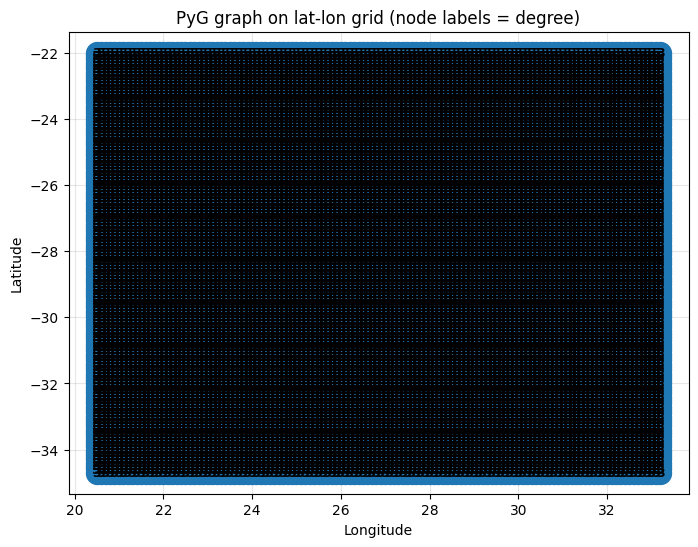

In [87]:
import torch
import matplotlib.pyplot as plt



lat = lat_high_graph.numpy()
lon = lon_high_graph.numpy()
deg = out_deg_high.numpy()

fig, ax = plt.subplots(figsize=(8, 6))



# Draw nodes
ax.scatter(lon, lat, s=250, zorder=3)

# Label nodes with degree
for i in range(len(lat)):
    ax.text(float(lon[i]), float(lat[i]), str(int(deg[i])),
            ha="center", va="center",
            fontsize=9, fontweight="bold",
            zorder=4)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("PyG graph on lat-lon grid (node labels = degree)")
ax.grid(True, alpha=0.3)
plt.show()


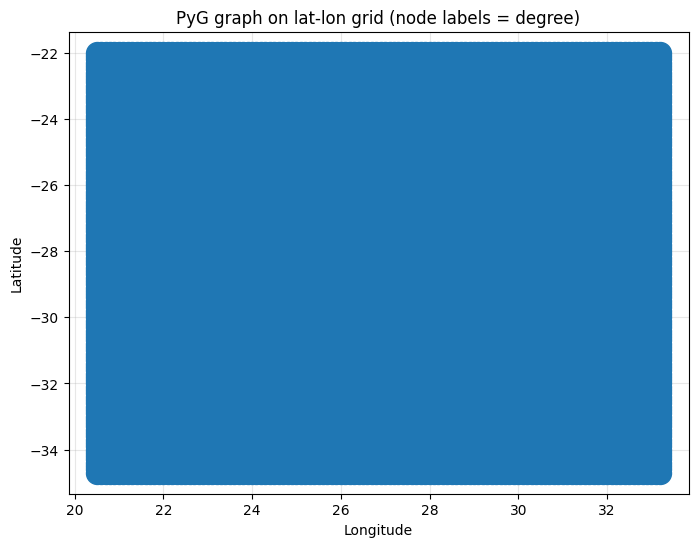

In [88]:



fig, ax = plt.subplots(figsize=(8, 6))




# Draw nodes
ax.scatter(lon, lat, s=250, zorder=3)



ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("PyG graph on lat-lon grid (node labels = degree)")
ax.grid(True, alpha=0.3)
plt.show()

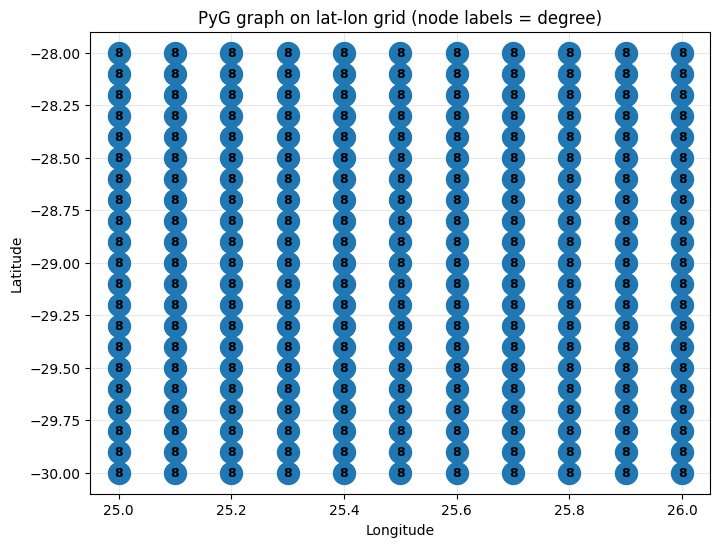

In [89]:


sel_lat = lat[selected_nodes_high]
sel_lon = lon[selected_nodes_high]
sel_deg = deg[selected_nodes_high]

fig, ax = plt.subplots(figsize=(8, 6))



# Draw nodes
ax.scatter(sel_lon, sel_lat, s=250, zorder=3)

# Label nodes with degree
for i in range(len(sel_lat)):
    ax.text(float(sel_lon[i]), float(sel_lat[i]), str(int(sel_deg[i])),
            ha="center", va="center",
            fontsize=9, fontweight="bold",
            zorder=4)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("PyG graph on lat-lon grid (node labels = degree)")
ax.grid(True, alpha=0.3)
plt.show()

In [90]:
print(np.min(deg), np.max(deg))

3.0 8.0
